In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))


Num GPUs Available:  1


Total images: 20
Total masks: 20
Train images: 15
Train masks: 15
Test images: 5
Test masks: 5
Datasets ready: train_ds, test_ds
Total patches: 100


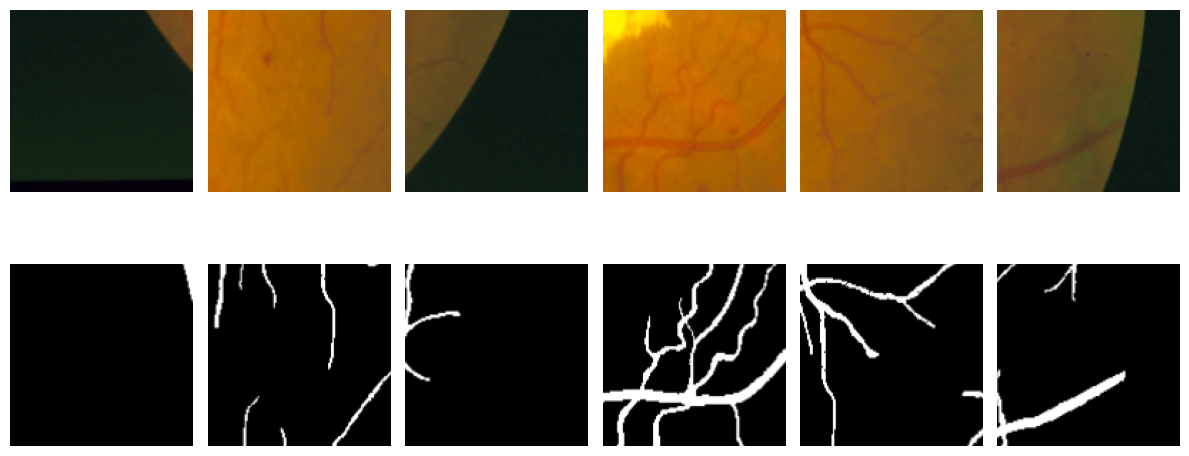

In [2]:
import os
import cv2
import numpy as np
import tensorflow as tf
import albumentations as A
import matplotlib.pyplot as plt
import random
import gzip
import shutil

# ================= PATHS =================
IMAGE_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\stare-images"
MASK_DIR = r"C:\Users\AUSTCSE4090\Desktop\STARE\stare\labels-ah"

# ================= CONSTANTS =================
RESIZE_SIZE = 704  # Resize original images to 768x768
IMG_SIZE = 128     # Patch size
OVERLAP = 0.5
BATCH_SIZE = 8

# ================= AUGMENTATION =================
augmenter = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        border_mode=cv2.BORDER_REFLECT,
        p=0.5
    ),
    A.RandomBrightnessContrast(p=0.3),
])

# ================= DECOMPRESSION FUNCTIONS =================
def decompress_ppm_gz(input_path, output_path):
    """Decompress .ppm.gz files to .ppm."""
    with gzip.open(input_path, 'rb') as f_in:
        with open(output_path, 'wb') as f_out:
            shutil.copyfileobj(f_in, f_out)

def decompress_all_files(image_dir, mask_dir):
    """Decompress all .ppm.gz files in image and mask directories."""
    for dir_path in [image_dir, mask_dir]:
        for filename in os.listdir(dir_path):
            if filename.endswith('.ppm.gz'):
                input_path = os.path.join(dir_path, filename)
                output_path = os.path.join(dir_path, filename.replace('.gz', ''))
                print(f"Decompressing: {filename}")
                decompress_ppm_gz(input_path, output_path)
                os.remove(input_path)  # Optionally remove the original .gz file

# ================= FUNCTIONS =================
def is_valid_patch(mask, threshold=0.01):
    """Check if the patch contains a significant portion of the object."""
    return np.count_nonzero(mask) / mask.size > threshold

def extract_patches(img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=True):
    """Extract patches from the image and mask."""
    stride = int(patch_size * (1 - overlap))
    patches_img = []
    patches_mask = []
    H, W = img.shape[:2]

    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            p_img = img[y:y+patch_size, x:x+patch_size]
            p_mask = mask[y:y+patch_size, x:x+patch_size]

            if skip_empty and not is_valid_patch(p_mask):
                continue

            patches_img.append(p_img)
            patches_mask.append(p_mask)

    return patches_img, patches_mask

def load_image_mask_paths(image_dir, mask_dir):
    """Load image and mask file paths."""
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith('.ppm')  # Now looking for .ppm files
    ])
    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith('.ppm')  # Looking for .ppm mask files
    ])
    return image_files, mask_files

def generator(image_paths, mask_paths, augment=True, skip_empty=True):
    """Generator function to yield image-mask pairs."""
    for img_path, mask_path in zip(image_paths, mask_paths):

        # Read images
        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Resize to 768x768
        img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
        mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

        # Extract patches
        patches_img, patches_mask = extract_patches(
            img, mask, IMG_SIZE, OVERLAP, skip_empty
        )

        for p_img, p_mask in zip(patches_img, patches_mask):

            if augment:
                data = augmenter(image=p_img, mask=p_mask)
                p_img, p_mask = data["image"], data["mask"]

            p_img = p_img.astype(np.float32) / 255.0
            p_mask = np.expand_dims(p_mask.astype(np.float32) / 255.0, axis=-1)

            yield p_img, p_mask

# ================= DECOMPRESS FILES =================
# Decompress all .ppm.gz files before loading them
decompress_all_files(IMAGE_DIR, MASK_DIR)

# ================= LOAD PATHS =================
all_images, all_masks = load_image_mask_paths(IMAGE_DIR, MASK_DIR)

# Debugging: Check if the images and masks were loaded correctly
print(f"Total images: {len(all_images)}")
print(f"Total masks: {len(all_masks)}")

# ===== Manual split: FIRST 15 → train, LAST 5 → test =====
train_images = all_images[:15]   # Use first 15 images for training
train_masks  = all_masks[:15]    # Use first 15 masks for training

test_images  = all_images[15:20]  # Use next 5 images for testing
test_masks   = all_masks[15:20]   # Use next 5 masks for testing

# Debugging: Print the size of training and testing splits
print(f"Train images: {len(train_images)}")  # Should print 15
print(f"Train masks: {len(train_masks)}")    # Should print 15
print(f"Test images: {len(test_images)}")    # Should print 5
print(f"Test masks: {len(test_masks)}")      # Should print 5

# ================= TF.DATA DATASETS =================
train_ds = tf.data.Dataset.from_generator(
    lambda: generator(train_images, train_masks, augment=True, skip_empty=True),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_generator(
    lambda: generator(test_images, test_masks, augment=False, skip_empty=False),
    output_signature=(
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 3), tf.float32),
        tf.TensorSpec((IMG_SIZE, IMG_SIZE, 1), tf.float32)
    )
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets ready: train_ds, test_ds")

# ================= VISUALIZATION =================
def visualize_patches(img_path, mask_path, num_samples=6):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    # Resize for visualization
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))
    mask = cv2.resize(mask, (RESIZE_SIZE, RESIZE_SIZE))

    patches_img, patches_mask = extract_patches(
        img, mask, patch_size=IMG_SIZE, overlap=OVERLAP, skip_empty=False
    )

    print(f"Total patches: {len(patches_img)}")

    indices = random.sample(range(len(patches_img)), min(num_samples, len(patches_img)))

    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(indices):
        plt.subplot(2, num_samples, i+1)
        plt.imshow(patches_img[idx])
        plt.axis("off")

        plt.subplot(2, num_samples, i+1+num_samples)
        plt.imshow(patches_mask[idx], cmap="gray")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Example visualization
visualize_patches(train_images[0], train_masks[0])


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, Model


# -------------------------
# Convolution Block
# -------------------------
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    return x


# -------------------------
# Encoder Block
# -------------------------
def encoder_block(x, filters):
    c = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2))(c)
    return c, p


# -------------------------
# Decoder Block
# -------------------------
def decoder_block(x, skip, filters):
    x = layers.Conv2DTranspose(filters, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)
    return x


# -------------------------
# Build U-Net (~5M params)
# -------------------------
def build_unet(input_shape=(128, 128, 3), base_filters=28):

    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, base_filters)          # 28
    s2, p2 = encoder_block(p1, base_filters * 2)          # 56
    s3, p3 = encoder_block(p2, base_filters * 4)          # 112
    s4, p4 = encoder_block(p3, base_filters * 8)          # 224

    # Bottleneck
    b1 = conv_block(p4, base_filters * 16)                 # 448

    # Decoder
    d1 = decoder_block(b1, s4, base_filters * 8)
    d2 = decoder_block(d1, s3, base_filters * 4)
    d3 = decoder_block(d2, s2, base_filters * 2)
    d4 = decoder_block(d3, s1, base_filters)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d4)

    model = Model(inputs, outputs, name="UNet_5M")
    return model


# -------------------------
# Create Model
# -------------------------
model = build_unet()
model.summary()


Model: "UNet_5M"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_19 (Conv2D)             (None, 128, 128, 28  784         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization_18 (BatchN  (None, 128, 128, 28  112        ['conv2d_19[0][0]']              
 ormalization)                  )                                                           

In [5]:
import tensorflow as tf
from tensorflow.keras import backend as K

def confusion_elements(y_true, y_pred):
    """Helper to calculate TP, TN, FP, FN"""
    y_pred = K.round(y_pred)
    y_true = K.round(y_true)
    TP = K.sum(y_true * y_pred)
    TN = K.sum((1 - y_true) * (1 - y_pred))
    FP = K.sum((1 - y_true) * y_pred)
    FN = K.sum(y_true * (1 - y_pred))
    return TP, TN, FP, FN

# Sensitivity (Recall)
def sensitivity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FN + K.epsilon())

# Specificity
def specificity(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TN / (TN + FP + K.epsilon())

# Accuracy
def accuracy(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return (TP + TN) / (TP + TN + FP + FN + K.epsilon())

# Precision
def precision(y_true, y_pred):
    TP, TN, FP, FN = confusion_elements(y_true, y_pred)
    return TP / (TP + FP + K.epsilon())

# F1-score
def f1_score(y_true, y_pred):
    prec = precision(y_true, y_pred)
    rec = sensitivity(y_true, y_pred)
    return 2 * ((prec * rec) / (prec + rec + K.epsilon()))

# AUC (use Keras built-in metric)
auc = tf.keras.metrics.AUC(name='auc')


smooth = 1e-6

def iou(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(K.round(y_pred), tf.float32)  # Round to binary
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(tf.cast(y_true, tf.float32))
    y_pred_f = K.flatten(K.round(y_pred))  # Round predictions to binary
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [7]:
import tensorflow as tf
from tensorflow.keras import backend as K

# ----------------------------------
# Tversky Index
# ----------------------------------
def tversky(y_true, y_pred, alpha=0.7, beta=0.3):
    # numerical stability
    y_pred = K.clip(y_pred, 1e-7, 1 - 1e-7)

    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    

    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1 - y_pred_pos))
    false_pos = K.sum((1 - y_true_pos) * y_pred_pos)

    return (true_pos + 1e-6) / (
        true_pos + alpha * false_neg + beta * false_pos + 1e-6
    )


# ----------------------------------
# Focal Tversky Loss
# ----------------------------------
def focal_tversky_loss(y_true, y_pred, gamma=0.75):
    tv = tversky(y_true, y_pred)
    return K.pow((1 - tv), gamma)


# ----------------------------------
# Hybrid Loss (Recommended)
# ----------------------------------
def hybrid_loss(y_true, y_pred):
    ft = focal_tversky_loss(y_true, y_pred)
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return 0.7 * ft + 0.3 * bce


In [8]:
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.optimizers import Adam


# Define Adam optimizer with an initial learning rate
initial_lr = 1e-4
optimizer = Adam(learning_rate=initial_lr)


def lr_schedule(epoch, lr):
    if epoch < 5:  # Warmup phase
        return lr * 1.5  # Increase LR to stabilize training
    elif epoch < 30:
        return lr * 0.98  # Gradual decay
    else:
        return lr * 0.95  # Final stabilization

lr_scheduler = LearningRateScheduler(lr_schedule)

In [9]:
from tensorflow.keras.losses import BinaryCrossentropy
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True),
    lr_scheduler
    #tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]



# Compile the model
model.compile(
    optimizer=optimizer,
    loss= hybrid_loss,  # Use BCE loss for binary segmentation
    metrics=[sensitivity, specificity, accuracy, f1_score, auc,dice_coef,iou]  # Your custom metrics
)


# Fit the model
history = model.fit(
    train_ds,
    #validation_data=test_ds,
     # optional if dataset is finite
    epochs=80,
)


Epoch 1/80
181/181 [==============================] - 10s 21ms/step - loss: 0.6807 - sensitivity: 0.8165 - specificity: 0.7377 - accuracy: 0.7444 - f1_score: 0.3898 - auc: 0.8473 - dice_coef: 0.3887 - iou: 0.2495
Epoch 2/80
181/181 [==============================] - 3s 15ms/step - loss: 0.5708 - sensitivity: 0.8473 - specificity: 0.9019 - accuracy: 0.8964 - f1_score: 0.5958 - auc: 0.9201 - dice_coef: 0.5927 - iou: 0.4264
Epoch 3/80
181/181 [==============================] - 3s 14ms/step - loss: 0.5188 - sensitivity: 0.8549 - specificity: 0.9270 - accuracy: 0.9199 - f1_score: 0.6558 - auc: 0.9339 - dice_coef: 0.6516 - iou: 0.4883
Epoch 4/80
181/181 [==============================] - 3s 15ms/step - loss: 0.4699 - sensitivity: 0.8634 - specificity: 0.9417 - accuracy: 0.9340 - f1_score: 0.6997 - auc: 0.9435 - dice_coef: 0.6944 - iou: 0.5359
Epoch 5/80
181/181 [==============================] - 3s 15ms/step - loss: 0.4333 - sensitivity: 0.8635 - specificity: 0.9508 - accuracy: 0.9422 - f1_s

Mean Dice        : 0.7842
Mean IoU         : 0.6495
Mean Accuracy    : 0.9723
Mean F1 Score    : 0.7842
Mean Sensitivity : 0.7535
Mean Specificity : 0.9888


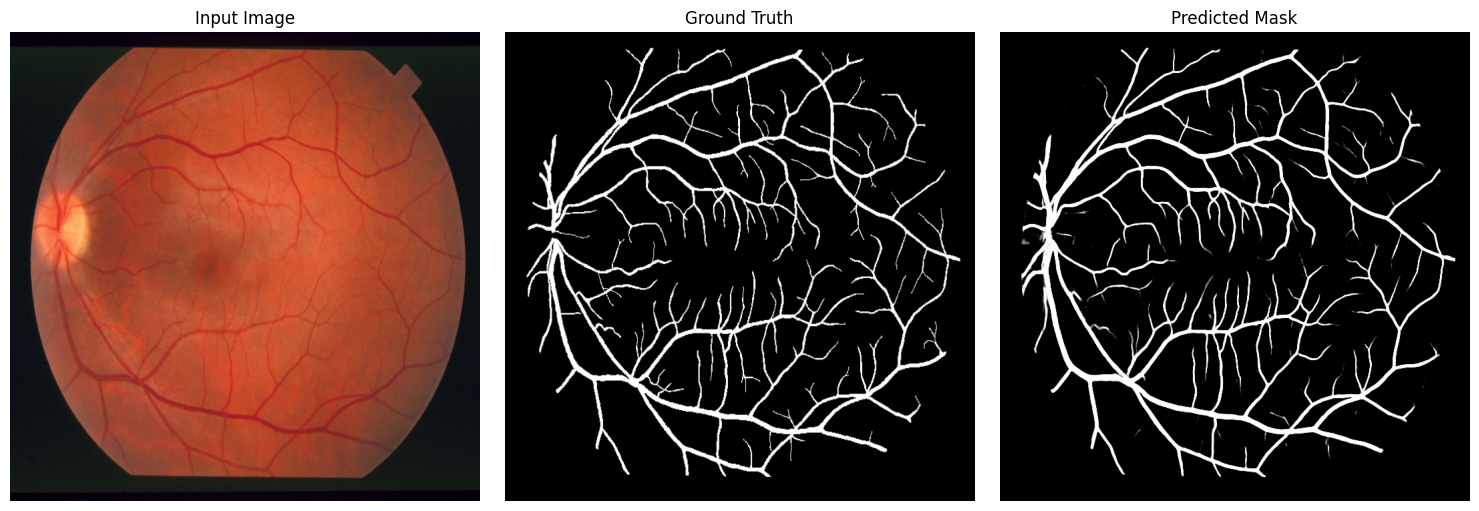

In [11]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

#================= CONSTANTS =================

RESIZE_SIZE = 704   # Full image resize
IMG_SIZE    = 128   # Patch size
OVERLAP     = 0.5   # 50% overlap
THRESHOLD   = 0.5   # Binarization threshold
BATCH_SIZE  = 16    # Mini-batch size for patch prediction

#================= PATCH FUNCTIONS =================

def extract_patches(img, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    H, W = img.shape[:2]
    patches = []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patches.append(img[y:y+patch_size, x:x+patch_size])
    return patches

def stitch_patches(patches, image_size=RESIZE_SIZE, patch_size=IMG_SIZE, overlap=OVERLAP):
    stride = int(patch_size * (1 - overlap))
    stitched_mask = np.zeros((image_size, image_size), dtype=np.float32)
    count_mask = np.zeros((image_size, image_size), dtype=np.float32)

    idx = 0  
    for y in range(0, image_size - patch_size + 1, stride):  
        for x in range(0, image_size - patch_size + 1, stride):  
            stitched_mask[y:y+patch_size, x:x+patch_size] += patches[idx]  
            count_mask[y:y+patch_size, x:x+patch_size] += 1  
            idx += 1  

    stitched_mask /= count_mask  
    return np.clip(stitched_mask, 0, 1)

#================= FULL IMAGE PREDICTION =================

def predict_full_image(model, img_path, batch_size=BATCH_SIZE):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (RESIZE_SIZE, RESIZE_SIZE))

    patches = extract_patches(img)  
    pred_patches = []  

    # Predict in mini-batches  
    for i in range(0, len(patches), batch_size):  
        batch = np.array([p.astype(np.float32)/255.0 for p in patches[i:i+batch_size]])  
        preds = model.predict(batch, verbose=0)  
        pred_patches.extend([p[:, :, 0] for p in preds])  # remove channel dim  

    full_mask = stitch_patches(pred_patches)  
    return img, full_mask

#================= EVALUATION FUNCTION =================

def evaluate_model(model, image_paths, mask_paths):
    dice_list, iou_list, acc_list, f1_list, sens_list, spec_list = [], [], [], [], [], []

    for img_path, mask_path in zip(image_paths, mask_paths):  
        img, pred_mask = predict_full_image(model, img_path)  

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  
        gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0  

        pred_bin = (pred_mask >= THRESHOLD).astype(np.float32)  
        gt_bin   = (gt_mask >= 0.5).astype(np.float32)  

        intersection = np.sum(pred_bin * gt_bin)  
        union = np.sum(pred_bin) + np.sum(gt_bin) - intersection  
        dice = (2 * intersection) / (np.sum(pred_bin) + np.sum(gt_bin) + 1e-7)  
        iou  = intersection / (union + 1e-7)  
        acc  = accuracy_score(gt_bin.flatten(), pred_bin.flatten())  
        f1   = f1_score(gt_bin.flatten(), pred_bin.flatten())  
        sens = recall_score(gt_bin.flatten(), pred_bin.flatten())  
        spec = (np.sum((1 - gt_bin) * (1 - pred_bin)) / np.sum(1 - gt_bin))  

        dice_list.append(dice)  
        iou_list.append(iou)  
        acc_list.append(acc)  
        f1_list.append(f1)  
        sens_list.append(sens)  
        spec_list.append(spec)  

    print(f"Mean Dice        : {np.mean(dice_list):.4f}")  
    print(f"Mean IoU         : {np.mean(iou_list):.4f}")  
    print(f"Mean Accuracy    : {np.mean(acc_list):.4f}")  
    print(f"Mean F1 Score    : {np.mean(f1_list):.4f}")  
    print(f"Mean Sensitivity : {np.mean(sens_list):.4f}")  
    print(f"Mean Specificity : {np.mean(spec_list):.4f}")

#================= VISUALIZATION =================

def visualize_prediction(model, img_path, mask_path):
    img, pred_mask = predict_full_image(model, img_path)
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

    plt.figure(figsize=(15,5))  
    plt.subplot(1,3,1)  
    plt.imshow(img)  
    plt.title("Input Image")  
    plt.axis("off")  

    plt.subplot(1,3,2)  
    plt.imshow(gt_mask, cmap="gray")  
    plt.title("Ground Truth")  
    plt.axis("off")  

    plt.subplot(1,3,3)  
    plt.imshow(pred_mask, cmap="gray")  
    plt.title("Predicted Mask")  
    plt.axis("off")  

    plt.tight_layout()  
    plt.show()

#================= USAGE =================

# Evaluate all test images
evaluate_model(model, test_images, test_masks)

# Visualize first test image
visualize_prediction(model, test_images[1], test_masks[1])


In [12]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph

def get_flops(model):
    input_shape = [1] + list(model.input_shape[1:])

    concrete = tf.function(lambda x: model(x))
    concrete_func = concrete.get_concrete_function(
        tf.TensorSpec(input_shape, model.inputs[0].dtype)
    )

    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(concrete_func)

    with tf.Graph().as_default() as graph:
        tf.graph_util.import_graph_def(graph_def, name='')

        run_meta = tf.compat.v1.RunMetadata()
        opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

        flops = tf.compat.v1.profiler.profile(
            graph=graph,
            run_meta=run_meta,
            cmd='op',
            options=opts
        )

    return flops.total_float_ops


In [13]:
flops = get_flops(model)
print("FLOPs:", flops)
print("GFLOPs:", flops / 1e9)


Instructions for updating:
Use `tf.compat.v1.graph_util.tensor_shape_from_node_def_name`
FLOPs: 4629454848
GFLOPs: 4.629454848


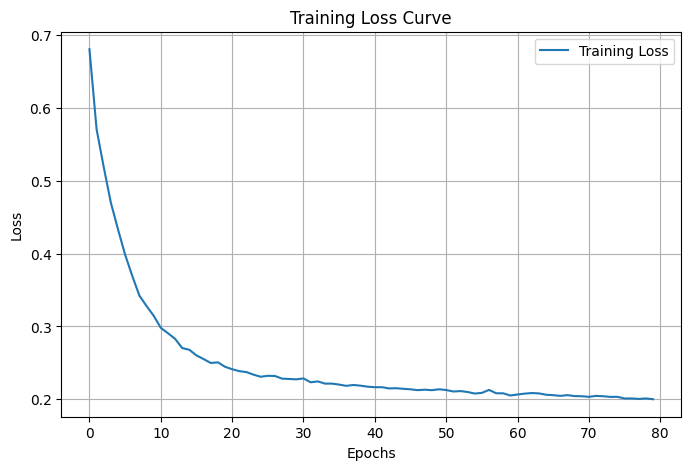

In [14]:
import matplotlib.pyplot as plt

# Plot Loss Curve
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
#plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Curve')
plt.legend()
plt.grid(True)
plt.show()


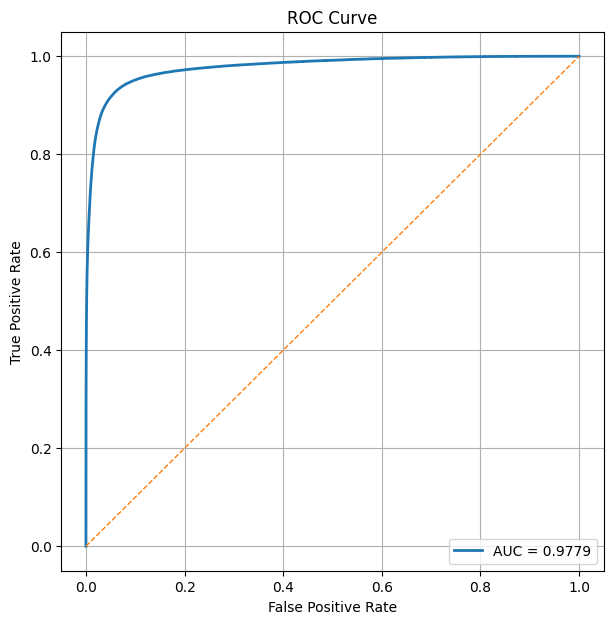

Global AUC: 0.9778892381289572


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
def plot_roc_curve(model, image_paths, mask_paths):
    all_gt = []
    all_pred = []

    for img_path, mask_path in zip(image_paths, mask_paths):
        _, pred_mask = predict_full_image(model, img_path)

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0

        gt_bin = (gt_mask >= 0.5).astype(np.uint8)

        all_gt.extend(gt_bin.flatten())
        all_pred.extend(pred_mask.flatten())

    all_gt = np.array(all_gt)
    all_pred = np.array(all_pred)

    # ROC + AUC
    fpr, tpr, thresholds = roc_curve(all_gt, all_pred)
    auc_score = roc_auc_score(all_gt, all_pred)

    # Plot
    plt.figure(figsize=(7,7))
    plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.4f}")
    plt.plot([0,1], [0,1], linestyle="--", linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    print("Global AUC:", auc_score)
plot_roc_curve(model, test_images, test_masks)


Metrics for Image 1: Sens: 0.743, Spec: 0.987, Acc: 0.962, F1: 0.799, Dice: 0.799, IoU: 0.665


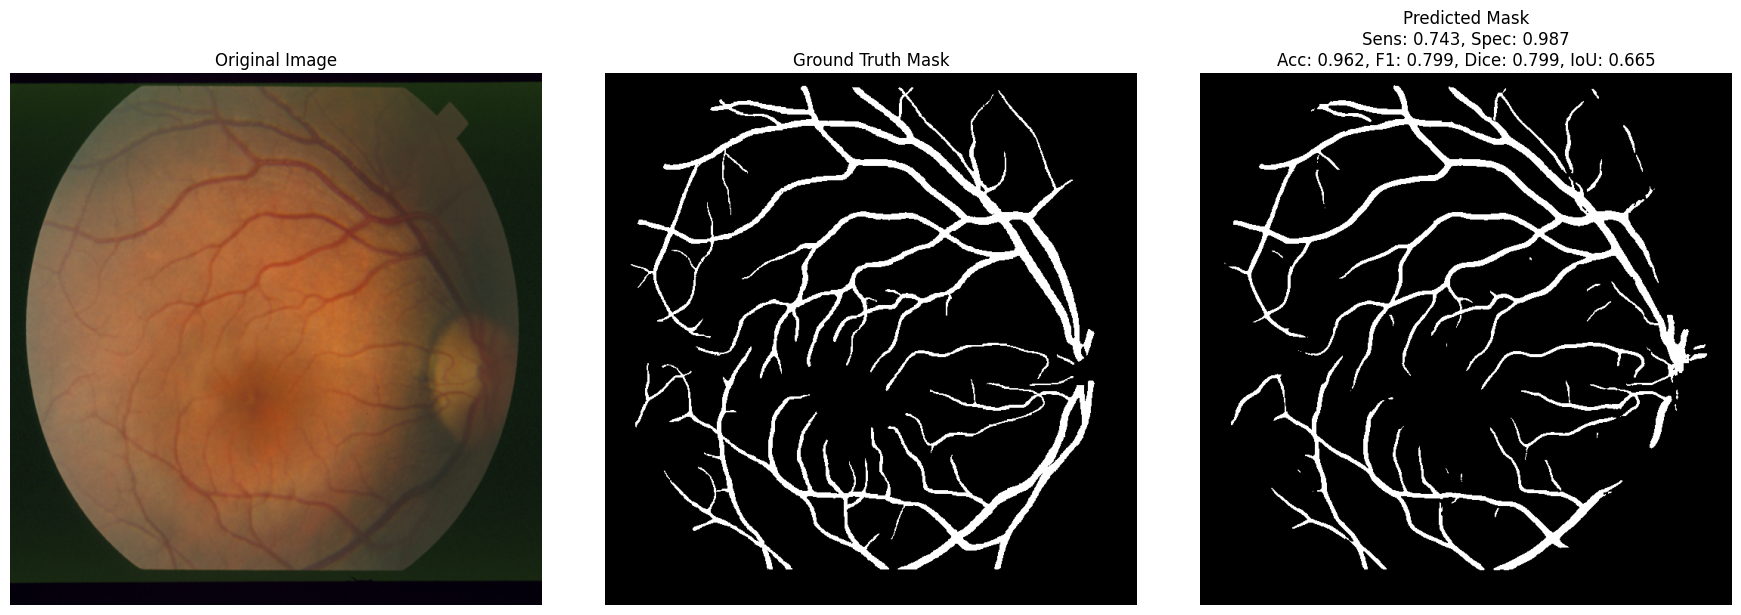

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_1.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_1.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_1.png
Metrics for Image 1 written to CSV.
Metrics for Image 2: Sens: 0.870, Spec: 0.984, Acc: 0.974, F1: 0.856, Dice: 0.856, IoU: 0.748


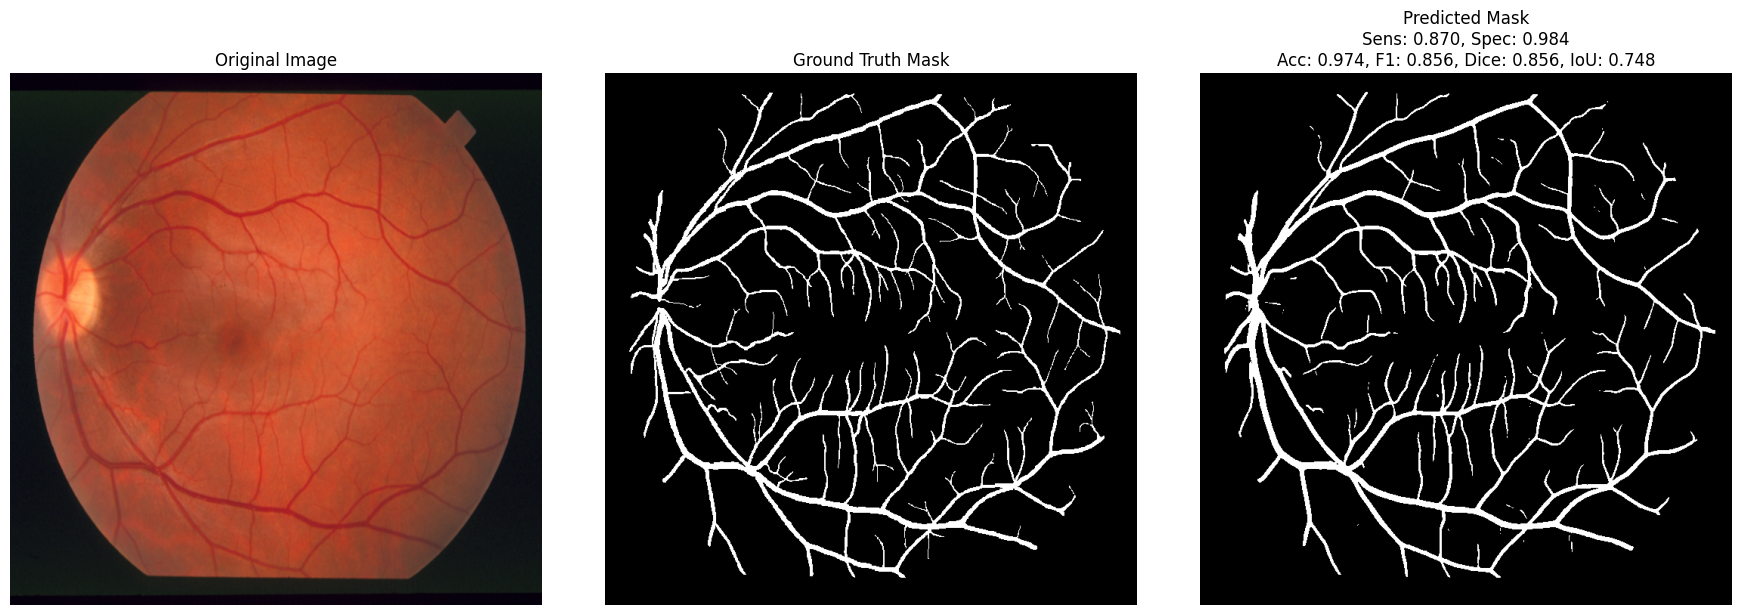

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_2.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_2.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_2.png
Metrics for Image 2 written to CSV.
Metrics for Image 3: Sens: 0.824, Spec: 0.990, Acc: 0.982, F1: 0.821, Dice: 0.821, IoU: 0.697


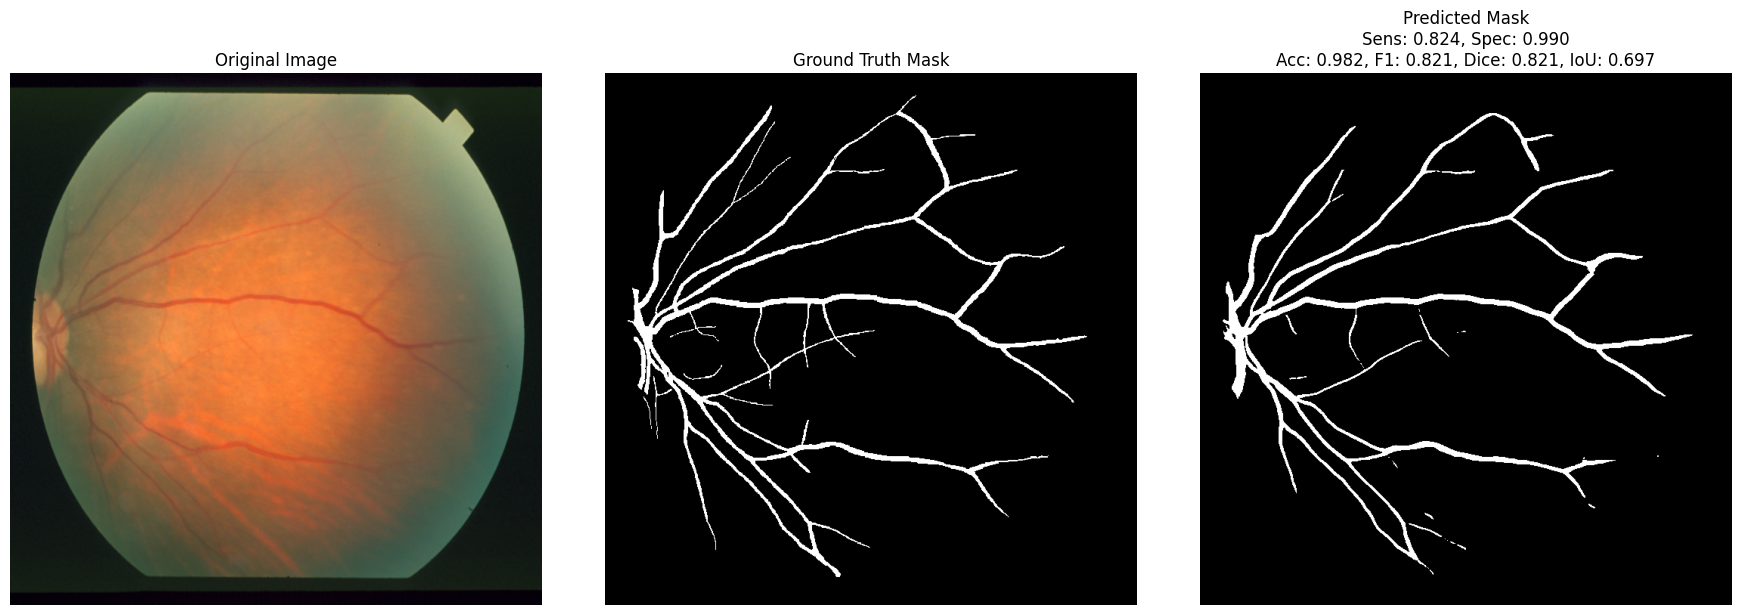

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_3.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_3.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_3.png
Metrics for Image 3 written to CSV.
Metrics for Image 4: Sens: 0.788, Spec: 0.990, Acc: 0.981, F1: 0.781, Dice: 0.781, IoU: 0.641


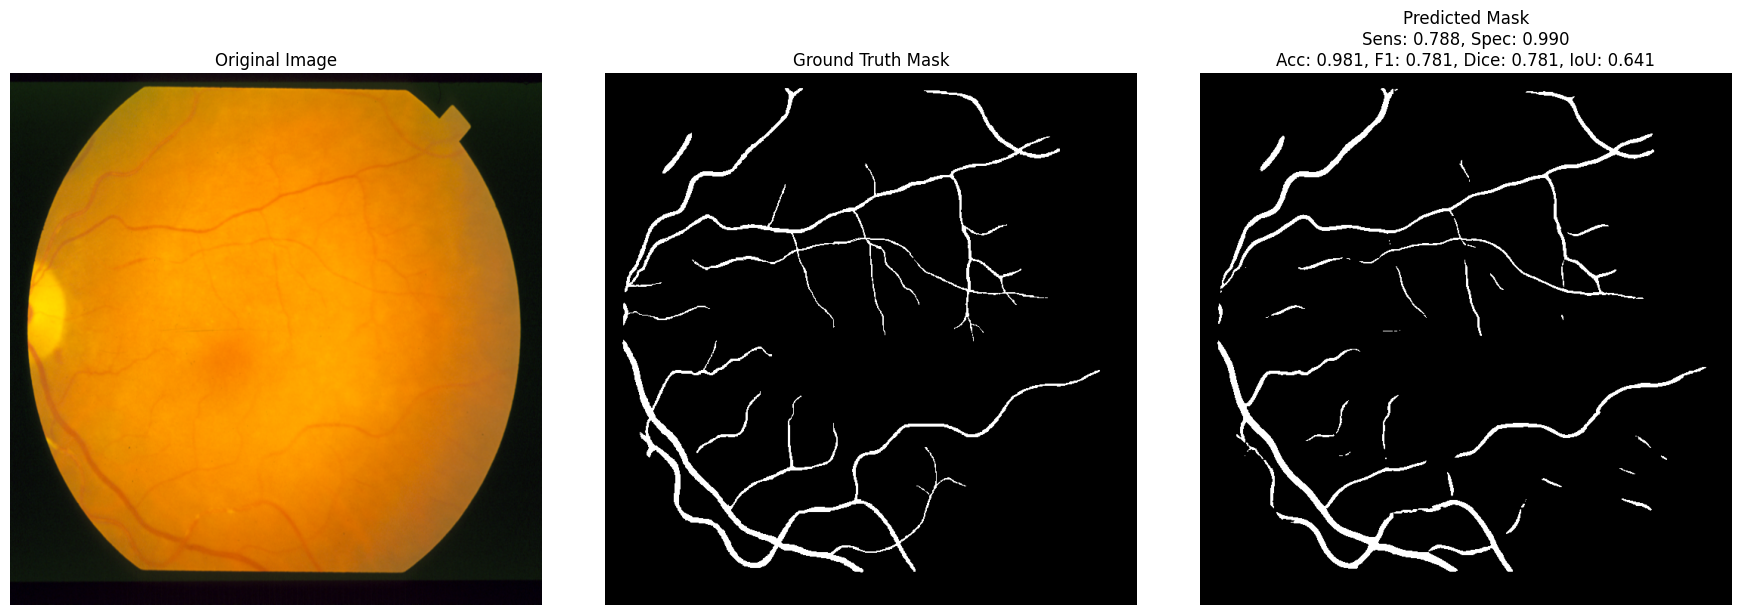

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_4.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_4.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_4.png
Metrics for Image 4 written to CSV.
Metrics for Image 5: Sens: 0.542, Spec: 0.993, Acc: 0.963, F1: 0.664, Dice: 0.664, IoU: 0.496


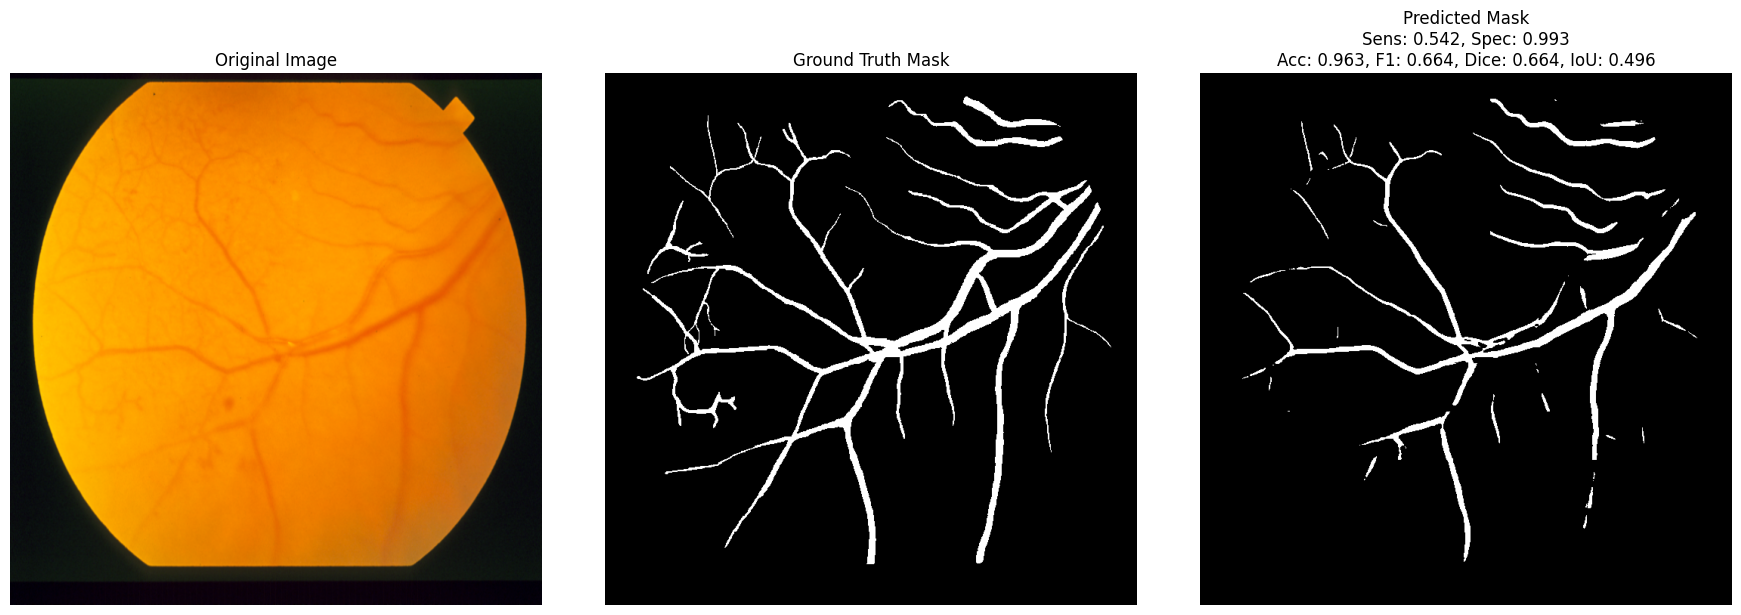

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_5.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_5.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_5.png
Metrics for Image 5 written to CSV.
All test image metrics saved to C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__metrics.csv


In [16]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import csv

# Directories to save predictions, ground truth masks, and original images
PREDICTIONS_DIR = r'C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask'
GROUND_TRUTH_DIR = r'C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask'
ORIGINAL_IMAGES_DIR = r'C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images'
os.makedirs(PREDICTIONS_DIR, exist_ok=True)
os.makedirs(GROUND_TRUTH_DIR, exist_ok=True)
os.makedirs(ORIGINAL_IMAGES_DIR, exist_ok=True)

# Constants
RESIZE_SIZE = 704
PATCH_SIZE  = 128
OVERLAP     = 0.5
STRIDE      = int(PATCH_SIZE * (1 - OVERLAP))
BATCH_SIZE  = 16
THRESHOLD   = 0.5
CSV_FILE = r"C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__metrics.csv"

# Define the function to save predicted masks
def save_predicted_mask(pred_mask, idx):
    mask_bin = (pred_mask > THRESHOLD).astype(np.uint8) * 255  # Binarize
    save_path = os.path.join(PREDICTIONS_DIR, f"predicted_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved predicted mask: {save_path}")

# Define the function to save ground truth masks
def save_ground_truth_mask(gt_mask, idx):
    mask_bin = (gt_mask * 255).astype(np.uint8)  # Ensure it is in 0-255 range
    save_path = os.path.join(GROUND_TRUTH_DIR, f"ground_truth_mask_{idx + 1}.png")
    cv2.imwrite(save_path, mask_bin)
    print(f"Saved ground truth mask: {save_path}")

# Define the function to save the original images
def save_original_image(img, idx):
    save_path = os.path.join(ORIGINAL_IMAGES_DIR, f"original_image_{idx + 1}.png")
    img_bgr = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)  # Convert RGB to BGR for saving with OpenCV
    cv2.imwrite(save_path, img_bgr)
    print(f"Saved original image: {save_path}")

# Function to compute per-image metrics
def compute_metrics_per_image(y_true, y_pred):
    y_true = y_true.astype(np.uint8)
    y_pred = y_pred.astype(np.uint8)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN + 1e-6)
    specificity = TN / (TN + FP + 1e-6)
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    precision = TP / (TP + FP + 1e-6)
    f1_score = 2 * precision * sensitivity / (precision + sensitivity + 1e-6)
    dice = 2 * TP / (2 * TP + FP + FN + 1e-6)
    iou = TP / (TP + FP + FN + 1e-6)

    return sensitivity, specificity, accuracy, f1_score, dice, iou

# Initialize CSV file and write header
def initialize_csv():
    with open(CSV_FILE, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Image_Index", "Sensitivity", "Specificity", "Accuracy", "F1_Score", "Dice", "IoU"])

# Write metrics to CSV
def write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou):
    with open(CSV_FILE, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([idx + 1, sens, spec, acc, f1, dice, iou])
    print(f"Metrics for Image {idx + 1} written to CSV.")

# Modify the visualization function to show original image, ground truth, and predicted mask
def visualize_metrics_and_save_prediction(model, img_path, mask_path, idx):
    # Predict mask for the image
    img, pred_mask = predict_full_image(model, img_path)  # Ensure this function is defined
    
    # Check if the prediction and image are correct
    if img is None or pred_mask is None:
        print(f"Prediction failed for image {img_path}")
        return

    # Read and preprocess the ground truth mask
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0
    
    # Apply thresholding to both ground truth and predicted masks to ensure they are binary
    gt_mask_bin = (gt_mask >= 0.5).astype(np.uint8)  # Ground truth as binary (0 or 1)
    pred_mask_bin = (pred_mask >= THRESHOLD).astype(np.uint8)  # Predicted mask as binary (0 or 1)
    
    # Compute metrics
    sens, spec, acc, f1, dice, iou = compute_metrics_per_image(gt_mask_bin, pred_mask_bin)
    
    # Print the metrics to verify if they are being calculated correctly
    print(f"Metrics for Image {idx + 1}: Sens: {sens:.3f}, Spec: {spec:.3f}, Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")

    # Plot the original image, ground truth, and predicted mask
    plt.figure(figsize=(18, 6))  # Increase the size to accommodate all 3 images
    
    # Original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    
    # Ground truth mask
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    # Predicted mask
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title(f"Predicted Mask\nSens: {sens:.3f}, Spec: {spec:.3f}\n"
              f"Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    # Save the original image, predicted mask, and ground truth mask
    save_original_image(img, idx)
    save_predicted_mask(pred_mask, idx)
    save_ground_truth_mask(gt_mask, idx)

    # Write the metrics to the CSV file
    write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou)

# Initialize the CSV file with the header
initialize_csv()

# Example usage: 
for idx, (img_path, mask_path) in enumerate(zip(test_images, test_masks)):
    visualize_metrics_and_save_prediction(model, img_path, mask_path, idx)

print(f"All test image metrics saved to {CSV_FILE}")


Metrics for Image 1: Sens: 0.743, Spec: 0.987, Acc: 0.962, F1: 0.799, Dice: 0.799, IoU: 0.665, AUC: 0.975


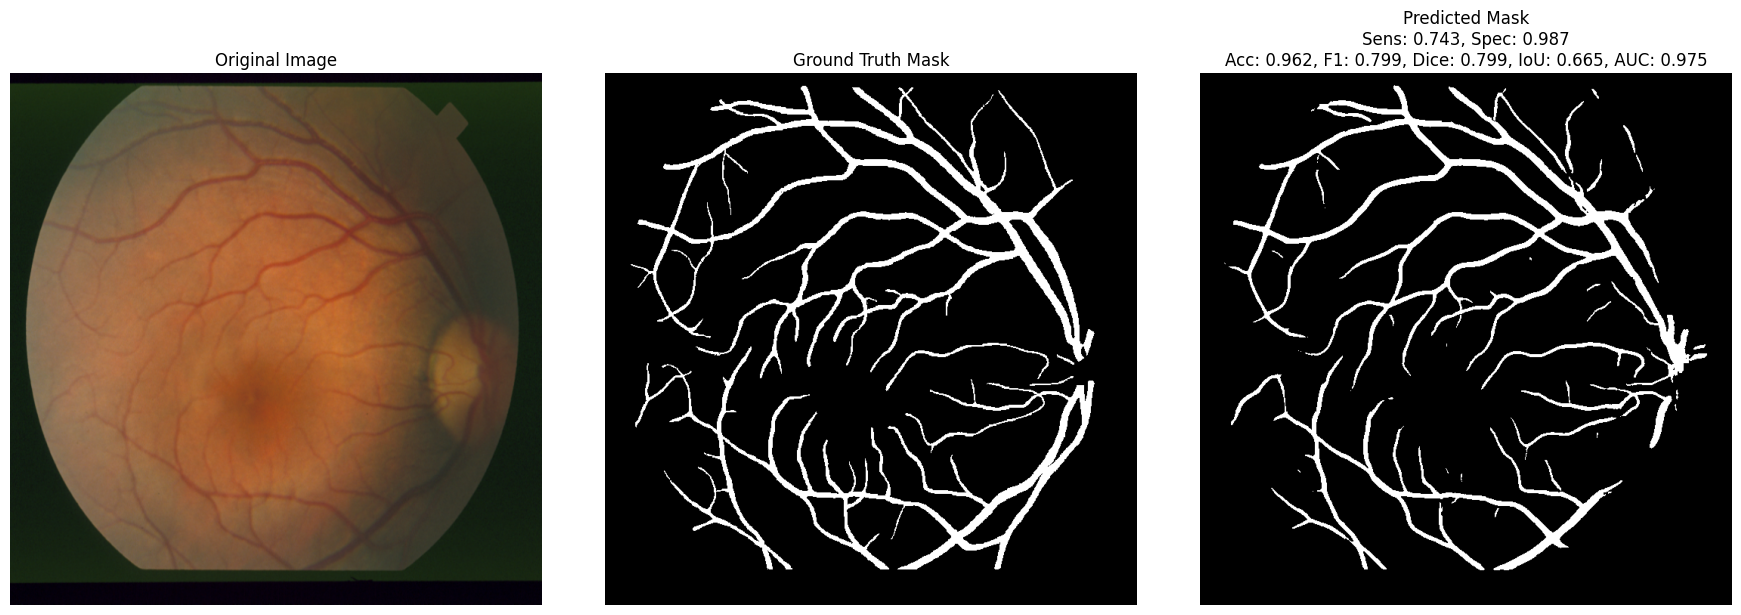

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_1.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_1.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_1.png
Metrics for Image 1 written to CSV.
Metrics for Image 2: Sens: 0.870, Spec: 0.984, Acc: 0.974, F1: 0.856, Dice: 0.856, IoU: 0.748, AUC: 0.991


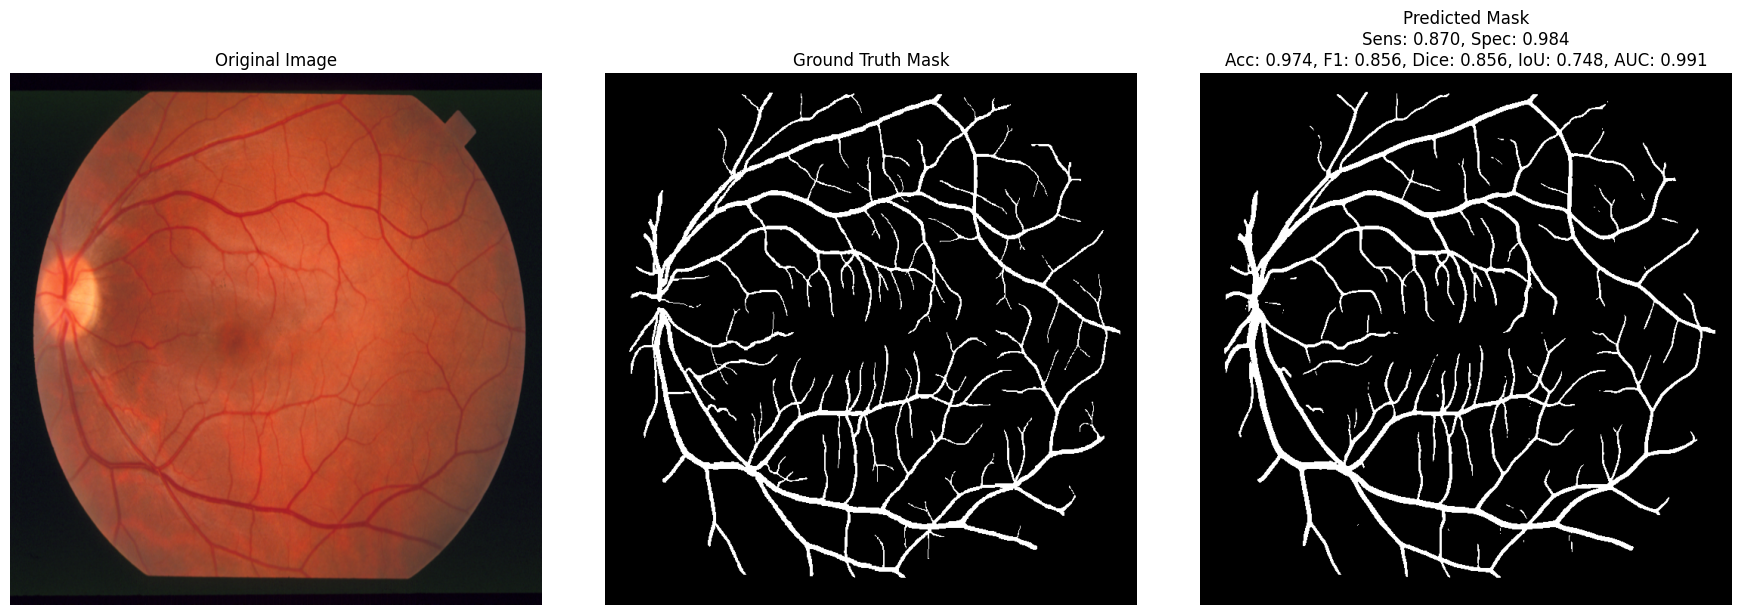

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_2.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_2.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_2.png
Metrics for Image 2 written to CSV.
Metrics for Image 3: Sens: 0.824, Spec: 0.990, Acc: 0.982, F1: 0.821, Dice: 0.821, IoU: 0.697, AUC: 0.986


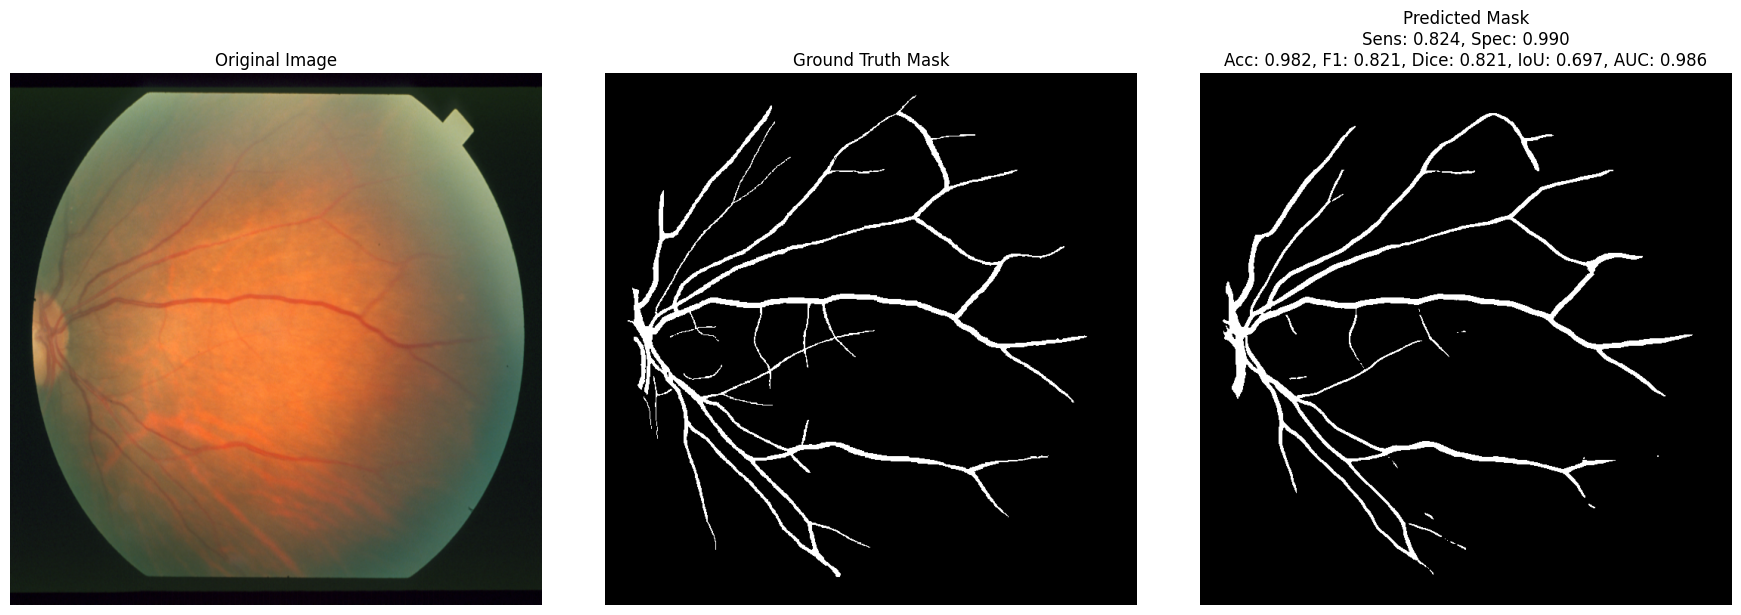

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_3.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_3.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_3.png
Metrics for Image 3 written to CSV.
Metrics for Image 4: Sens: 0.788, Spec: 0.990, Acc: 0.981, F1: 0.781, Dice: 0.781, IoU: 0.641, AUC: 0.988


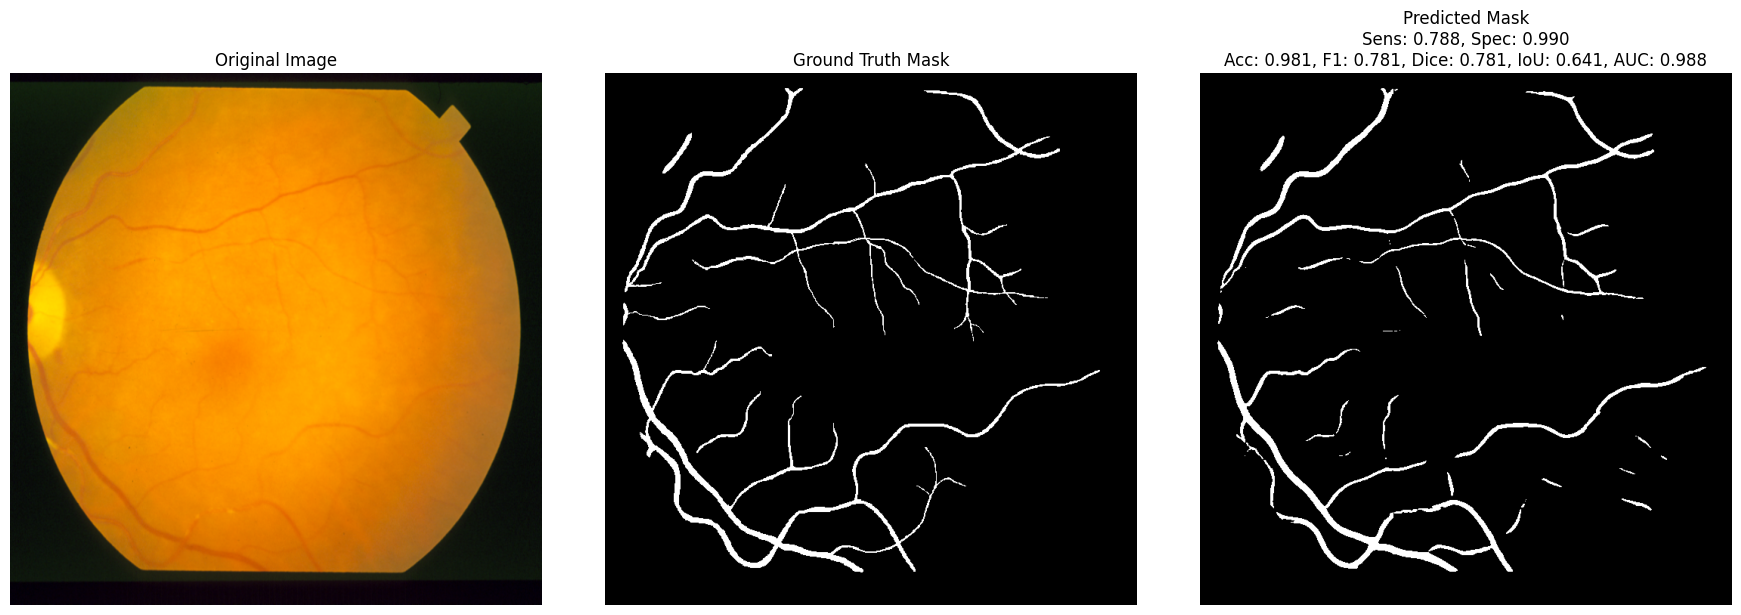

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_4.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_4.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_4.png
Metrics for Image 4 written to CSV.
Metrics for Image 5: Sens: 0.542, Spec: 0.993, Acc: 0.963, F1: 0.664, Dice: 0.664, IoU: 0.496, AUC: 0.962


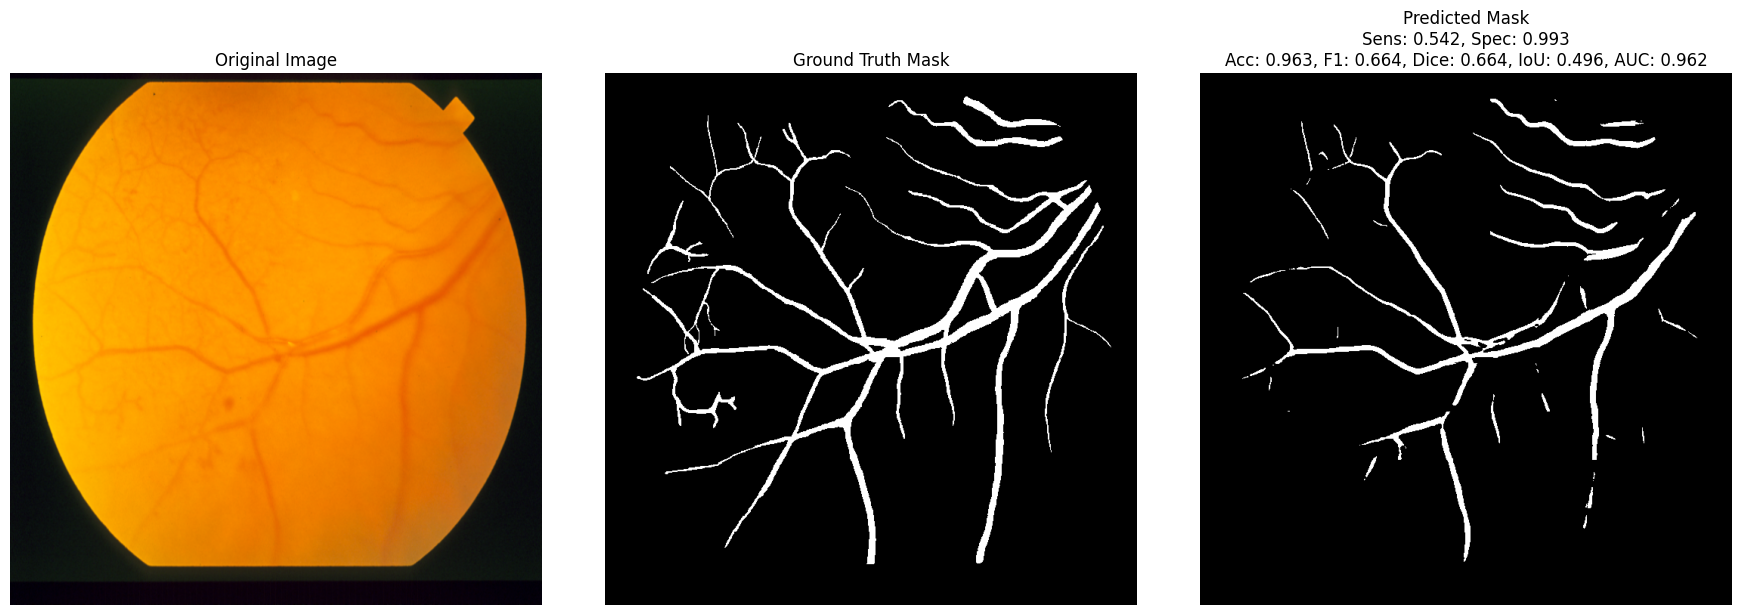

Saved original image: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unetL_original_images\original_image_5.png
Saved predicted mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet___predicted_mask\predicted_mask_5.png
Saved ground truth mask: C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__ground_truth_mask\ground_truth_mask_5.png
Metrics for Image 5 written to CSV.
All test image metrics including AUC saved to C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet__metrics.csv


In [17]:
from sklearn.metrics import roc_auc_score

# Update CSV header to include AUC
def initialize_csv():
    with open(CSV_FILE, mode='w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(["Image_Index", "Sensitivity", "Specificity", "Accuracy", "F1_Score", "Dice", "IoU", "AUC"])

# Update CSV writer to include AUC
def write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou, auc):
    with open(CSV_FILE, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([idx + 1, sens, spec, acc, f1, dice, iou, auc])
    print(f"Metrics for Image {idx + 1} written to CSV.")

# Modify visualization function to compute AUC
def visualize_metrics_and_save_prediction(model, img_path, mask_path, idx):
    # Predict mask for the image
    img, pred_mask = predict_full_image(model, img_path)
    
    if img is None or pred_mask is None:
        print(f"Prediction failed for image {img_path}")
        return

    # Read and preprocess the ground truth mask
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (RESIZE_SIZE, RESIZE_SIZE)) / 255.0
    
    # Binary masks
    gt_mask_bin = (gt_mask >= 0.5).astype(np.uint8)
    pred_mask_bin = (pred_mask >= THRESHOLD).astype(np.uint8)

    # Compute metrics
    sens, spec, acc, f1, dice, iou = compute_metrics_per_image(gt_mask_bin, pred_mask_bin)

    # Compute pixel-wise AUC safely
    try:
        auc = roc_auc_score(gt_mask_bin.flatten(), pred_mask.flatten())
    except:
        auc = np.nan

    # Print metrics
    print(f"Metrics for Image {idx + 1}: Sens: {sens:.3f}, Spec: {spec:.3f}, Acc: {acc:.3f}, "
          f"F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}, AUC: {auc:.3f}")

    # Plot original, GT, and predicted mask
    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis("off")
    
    plt.subplot(1, 3, 2)
    plt.imshow(gt_mask_bin, cmap='gray')
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask_bin, cmap='gray')
    plt.title(f"Predicted Mask\nSens: {sens:.3f}, Spec: {spec:.3f}\n"
              f"Acc: {acc:.3f}, F1: {f1:.3f}, Dice: {dice:.3f}, IoU: {iou:.3f}, AUC: {auc:.3f}")
    plt.axis("off")
    
    plt.tight_layout()
    plt.show()

    # Save original image, predicted mask, and GT mask
    save_original_image(img, idx)
    save_predicted_mask(pred_mask, idx)
    save_ground_truth_mask(gt_mask, idx)

    # Write metrics to CSV
    write_metrics_to_csv(idx, sens, spec, acc, f1, dice, iou, auc)

# Initialize CSV
initialize_csv()

# Run for all test images
for idx, (img_path, mask_path) in enumerate(zip(test_images, test_masks)):
    visualize_metrics_and_save_prediction(model, img_path, mask_path, idx)

print(f"All test image metrics including AUC saved to {CSV_FILE}")


In [18]:
model.save_weights(
    r"C:\Users\AUSTCSE4090\Desktop\stare\predcited_mask\unet model_weights.h5"
)
print("Weights saved successfully")


Weights saved successfully


In [19]:
from tensorflow.keras import backend as K

# Clear any previous models and free memory
K.clear_session()